<h1 style="margin:0;color:#3776AB;">
🐍 Pythonize com Tomane | #011
</h1>

### Agronomia com Python

### 💡 Como acompanhar a evolução de uma doença no milho e visualizar, no mesmo painel, dados do solo e do clima?

#### Neste tutorial, vamos criar quatro gráficos com dados simulados: progresso da doença, chuva e temperatura, pH e carbono orgânico do solo, e humidade versus severidade.

#### 1. Instalar e importar as bibliotecas

In [1]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

#### 2. Preparar os dados simulados

In [3]:
semanas = np.arange(1, 13)
dias = (semanas - 1) * 7

plantas_avaliadas = 100
plantas_com_sintomas = np.array(
    [5, 8, 14, 20, 28, 35, 39, 42, 44, 47, 50, 52]
)

# Percentagem média da área foliar afetada nas folhas avaliadas
severidade = np.array(
    [1, 2, 4, 6, 9, 12, 15, 18, 20, 22, 24, 25]
)

chuva_mm = np.array(
    [24, 35, 49, 71, 62, 83, 95, 78, 65, 73, 58, 45]
)

temperatura_c = np.array(
    [29, 29, 28, 27, 27, 26, 26, 27, 28, 28, 29, 30]
)

umidade_pct = np.array(
    [61, 64, 68, 73, 76, 81, 85, 83, 79, 78, 74, 69]
)

setores = ["A", "B", "C", "D", "E", "F"]
ph_solo = np.array([5.1, 5.6, 6.0, 5.4, 6.3, 5.8])
carbono_organico_pct = np.array([0.8, 1.1, 1.3, 0.9, 1.6, 1.2])

#### 3. Calcular os indicadores da doença

In [4]:
incidencia = plantas_com_sintomas / plantas_avaliadas * 100

# Área abaixo da curva de progresso da incidência
audpc = np.trapezoid(incidencia, x=dias)

print(f"Incidência na semana 12: {incidencia[-1]:.1f}%")
print(f"Severidade na semana 12: {severidade[-1]:.1f}%")
print(f"AUDPC da incidência: {audpc:.1f} %·dia")

Incidência na semana 12: 52.0%
Severidade na semana 12: 25.0%
AUDPC da incidência: 2488.5 %·dia


Incidência representa a proporção de plantas com sintomas; severidade representa a proporção de tecido afetado. São medidas diferentes e devem ser registadas com critérios consistentes no campo.

#### 4. Criar os gráficos

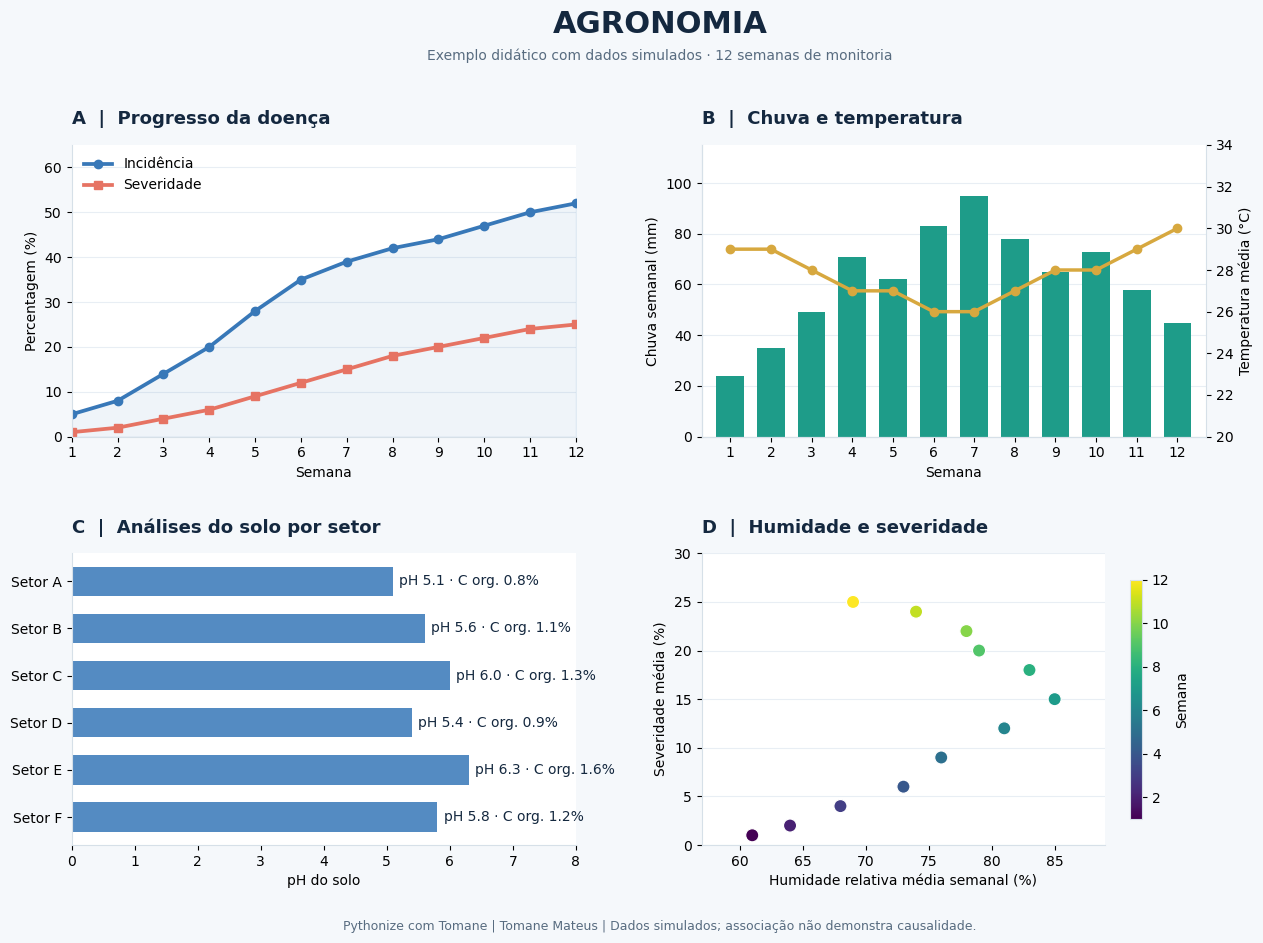

Gráfico guardado em: C:\Users\Tomane Asus\Pythonize_011_Painel_Fitopatologia_Solo_Clima.png


In [6]:
AZUL = "#3878B8"
VERDE = "#1E9C89"
CORAL = "#E67363"
DOURADO = "#D7A83F"
ESCURO = "#14283F"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.edgecolor": "#D6E0E8",
    "figure.facecolor": "#F5F8FB",
})

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(
    left=0.08, right=0.89, top=0.84,
    bottom=0.14, wspace=0.25, hspace=0.40
)

fig.suptitle(
    "AGRONOMIA",
    y=0.975, fontsize=22, fontweight="bold", color=ESCURO
)

fig.text(
    0.5, 0.925,
    "Exemplo didático com dados simulados · 12 semanas de monitoria",
    ha="center", color="#586C80"
)

def preparar_grafico(ax, titulo):
    ax.set_facecolor("white")
    ax.set_title(titulo, loc="left", pad=15,
                 fontweight="bold", color=ESCURO)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E8EEF4", linewidth=0.8)
    ax.set_axisbelow(True)

# A — Progresso da doença
ax = axs[0, 0]
preparar_grafico(ax, "A  |  Progresso da doença")

ax.plot(semanas, incidencia, color=AZUL, linewidth=2.7,
        marker="o", label="Incidência")
ax.plot(semanas, severidade, color=CORAL, linewidth=2.7,
        marker="s", label="Severidade")
ax.fill_between(semanas, incidencia, color=AZUL, alpha=0.08)

ax.set(xlabel="Semana", ylabel="Percentagem (%)",
       xlim=(1, 12), ylim=(0, 65))
ax.set_xticks(semanas)
ax.legend(frameon=False, loc="upper left")

# B — Chuva e temperatura
ax = axs[0, 1]
preparar_grafico(ax, "B  |  Chuva e temperatura")

ax.bar(semanas, chuva_mm, color=VERDE, width=0.68)
ax.set(xlabel="Semana", ylabel="Chuva semanal (mm)",
       xlim=(0.3, 12.7), ylim=(0, 115))
ax.set_xticks(semanas)

ax2 = ax.twinx()
ax2.plot(semanas, temperatura_c, color=DOURADO,
         linewidth=2.5, marker="o")
ax2.set(ylabel="Temperatura média (°C)", ylim=(20, 34))
ax2.spines["top"].set_visible(False)

# C — Análises do solo
ax = axs[1, 0]
preparar_grafico(ax, "C  |  Análises do solo por setor")

posicoes = np.arange(len(setores))
ax.barh(posicoes, ph_solo, color=AZUL, height=0.62, alpha=0.86)
ax.set_yticks(posicoes, [f"Setor {s}" for s in setores])
ax.invert_yaxis()
ax.set(xlabel="pH do solo", xlim=(0, 8))
ax.grid(axis="y", visible=False)

for posicao, ph, carbono in zip(
    posicoes, ph_solo, carbono_organico_pct
):
    ax.text(
        ph + 0.1, posicao,
        f"pH {ph:.1f} · C org. {carbono:.1f}%",
        va="center", color=ESCURO
    )

# D — Humidade e severidade
ax = axs[1, 1]
preparar_grafico(ax, "D  |  Humidade e severidade")

escala = Normalize(vmin=1, vmax=12)
ax.scatter(
    umidade_pct, severidade,
    c=semanas, cmap="viridis", norm=escala,
    s=90, edgecolors="white", linewidths=0.9
)

ax.set(
    xlabel="Humidade relativa média semanal (%)",
    ylabel="Severidade média (%)",
    xlim=(57, 89), ylim=(0, 30)
)

fig.colorbar(
    ScalarMappable(norm=escala, cmap="viridis"),
    ax=ax, label="Semana", shrink=0.82
)

fig.text(
    0.5, 0.055,
    "Pythonize com Tomane | Tomane Mateus | "
    "Dados simulados; associação não demonstra causalidade.",
    ha="center", color="#586C80", fontsize=9
)

saida = Path("Pythonize_011_Painel_Fitopatologia_Solo_Clima.png")
fig.savefig(saida, dpi=180, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado em: {saida.resolve()}")

O pH influencia a disponibilidade de nutrientes, mas a interpretação agronómica depende da cultura e das análises do solo. Do mesmo modo, uma associação entre humidade e severidade não prova que a humidade causou o aumento observado; doenças de plantas envolvem hospedeiro, agente patogénico e ambiente.

<h3 style="margin-bottom:5px;">
Tomane Mateus
</h3>

<p style="margin-top:0;">
</p>

<p>
🔗 <b>LinkedIn:</b>
<a href="https://www.linkedin.com/in/tomane-mateus-tomane-7a5205123" target="_blank">
www.linkedin.com/in/tomane-mateus-tomane-7a5205123
</a>
</p>
<p>
💻 <b>GitHub:</b>
<a href="https://github.com/Tomane-Pd" target="_blank">
github.com/Tomane-Pd
</a>
</p>
<p>
🌐 <b>Portfolio:</b>
<a href="https://tomane-portfolio.com" target="_blank">
tomane-portfolio.com
</a>
</p>

<hr style="border:1px solid #ddd; width:100%;">

<p style="color:#555;">
 <b>Siga para mais dicas práticas de Python, IA, Data Science e Automação.</b>
</p>

<p style="font-size:13px;color:#888;margin-top:15px;">
© 2026 <b>Tomane Mateus</b>. Todos os direitos reservados.
</p>

</div>